In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import community

# Matplotlib setting agar visualisasi muncul di notebook
%matplotlib inline

In [30]:
# Memanggil file yang sudah kamu siapkan dan bersihkan
df = pd.read_csv('maskapai_asean_final.csv')

# Memastikan data Hub tidak kosong untuk analisis graf yang akurat
df_graph = df[df['hubLabel'] != "-"].dropna(subset=['hubLabel']).copy()

print(f"Data Berhasil Dimuat! Total: {len(df_graph)} entitas maskapai siap dianalisis.")
df_graph.head()

Data Berhasil Dimuat! Total: 181 entitas maskapai siap dianalisis.


,airline,airlineLabel,countryLabel,hub,hubLabel,iataCode
0,http://www.wikidata.org/entity/Q123964838,GallopAir,Brunei,http://www.wikidata.org/entity/Q1148514,Bandar Udara Internasional Brunei,NaN
1,http://www.wikidata.org/entity/Q1050783,Royal Brunei Airlines,Brunei,http://www.wikidata.org/entity/Q1148514,Bandar Udara Internasional Brunei,BI
2,http://www.wikidata.org/entity/Q4633116,2GO Air,Filipina,http://www.wikidata.org/entity/Q86446,Bandar Udara Internasional Ninoy Aquino,NaN
3,http://www.wikidata.org/entity/Q4688148,Aero Majestic Airways,Filipina,http://www.wikidata.org/entity/Q1200033,Bandar Udara Internasional Zamboanga,NaN
4,http://www.wikidata.org/entity/Q4688288,Aerolift Philippines,Filipina,http://www.wikidata.org/entity/Q86446,Bandar Udara Internasional Ninoy Aquino,NaN


In [31]:
G = nx.Graph()

for _, row in df_graph.iterrows():
    airline = row['airlineLabel']
    country = row['countryLabel']
    hub = row['hubLabel']
    
    # Menambahkan nodes dengan tipe untuk mempermudah filter algoritma
    G.add_node(airline, type='Airline')
    G.add_node(country, type='Country')
    G.add_node(hub, type='Hub')
    
    # Menambahkan hubungan (Edges)
    G.add_edge(airline, country)
    G.add_edge(airline, hub)

print(f"Graf berhasil dibangun: {G.number_of_nodes()} Node & {G.number_of_edges()} Edge.")

Graf berhasil dibangun: 236 Node & 360 Edge.


In [32]:
# PageRank untuk melihat negara dengan pengaruh konektivitas terbesar
pagerank_all = nx.pagerank(G)
country_rank = {node: score for node, score in pagerank_all.items() if G.nodes[node]['type'] == 'Country'}

# Sorting dan mengambil Top 5
sorted_country = sorted(country_rank.items(), key=lambda x: x[1], reverse=True)

print("### ANALISIS 1: ASEAN POWER RANKING (TOP 5 COUNTRY DOMINANCE) ###")
for i, (name, score) in enumerate(sorted_country[:5]):
    print(f"{i+1}. {name:15} | PageRank Score: {score:.4f}")

### ANALISIS 1: ASEAN POWER RANKING (TOP 5 COUNTRY DOMINANCE) ###
1. Indonesia       | PageRank Score: 0.0650
2. Thailand        | PageRank Score: 0.0359
3. Filipina        | PageRank Score: 0.0326
4. Malaysia        | PageRank Score: 0.0305
5. Kamboja         | PageRank Score: 0.0177


In [34]:
# Gabungan Degree Centrality (Popularitas) dan PageRank (Prestise)
degree_cent = nx.degree_centrality(G)

hub_importance = []
for node in G.nodes():
    if G.nodes[node]['type'] == 'Hub':
        # Menggabungkan bobot volume koneksi dan kualitas koneksi
        score = (degree_cent[node] + pagerank_all[node]) / 2
        hub_importance.append((node, score))

sorted_hubs = sorted(hub_importance, key=lambda x: x[1], reverse=True)

print("### ANALISIS 2: PUBLIC IMPORTANCE SCORE (TOP 5 STRATEGIC HUBS) ###")
for i, (name, score) in enumerate(sorted_hubs[:5]):
    print(f"{i+1}. {name:45} | Importance: {score:.4f}")

### ANALISIS 2: PUBLIC IMPORTANCE SCORE (TOP 5 STRATEGIC HUBS) ###
1. Bandar Udara Internasional Soekarno-Hatta     | Importance: 0.0573
2. Bandar Udara Internasional Suvarnabhumi       | Importance: 0.0403
3. Bandar Udara Internasional Don Mueang         | Importance: 0.0403
4. Bandar Udara Internasional Ninoy Aquino       | Importance: 0.0382
5. Bandar Udara Internasional Phnom Penh         | Importance: 0.0299


In [35]:
# Mencari bandara jembatan yang paling kritis bagi aliran rute
betweenness = nx.betweenness_centrality(G)
hub_bw = {node: score for node, score in betweenness.items() if G.nodes[node]['type'] == 'Hub'}

sorted_bw = sorted(hub_bw.items(), key=lambda x: x[1], reverse=True)

print("### ANALISIS 3: THE INVISIBLE BOTTLENECK (TOP 5 CRITICAL BRIDGES) ###")
for i, (name, score) in enumerate(sorted_bw[:5]):
    print(f"{i+1}. {name:45} | Betweenness: {score:.4f}")

### ANALISIS 3: THE INVISIBLE BOTTLENECK (TOP 5 CRITICAL BRIDGES) ###
1. Bandar Udara Internasional Soekarno-Hatta     | Betweenness: 0.0038
2. Bandar Udara Internasional Suvarnabhumi       | Betweenness: 0.0019
3. Bandar Udara Internasional Don Mueang         | Betweenness: 0.0019
4. Bandar Udara Internasional Ninoy Aquino       | Betweenness: 0.0017
5. Bandar Udara Internasional Phnom Penh         | Betweenness: 0.0010


In [37]:
# Mencari titik kritis yang jika terputus akan membelah jaringan
art_points = list(nx.articulation_points(G))

print("### ANALISIS 4: NETWORK RESILIENCE (ARTICULATION POINTS) ###")
print("Entitas berikut adalah titik kritis bagi ketahanan jaringan udara ASEAN:")
for p in art_points[:5]: 
    ntype = G.nodes[p].get('type', 'Unknown')
    print(f"- [{ntype}] {p}")

### ANALISIS 4: NETWORK RESILIENCE (ARTICULATION POINTS) ###
Entitas berikut adalah titik kritis bagi ketahanan jaringan udara ASEAN:
- [Country] Filipina
- [Airline] Laoag International Airlines
- [Airline] Pacific Pearl Airways
- [Airline] Pan Pacific Airlines
- [Country] Indonesia


In [38]:
# Menggunakan Greedy Modularity untuk melihat pengelompokan alami
communities = list(community.greedy_modularity_communities(G))

print(f"### ANALISIS 5: REGIONAL INTEGRATION (DETECTED {len(communities)} COMMUNITIES) ###")

# Mencari klaster yang mengandung elemen kunci IMT-GT
imt_gt_keys = ["Kuala Namu", "Penang", "Kuala Lumpur", "Sultan Iskandar Muda"]

for i, comm in enumerate(communities):
    found = [n for n in comm if any(k in n for k in imt_gt_keys)]
    if found:
        print(f"\nKlaster {i+1} terdeteksi memiliki elemen IMT-GT:")
        print(f"Nodes Ditemukan: {found}")
        # Menampilkan maskapai dominan di klaster ini
        airlines = [n for n in comm if G.nodes[n]['type'] == 'Airline'][:3]
        print(f"Contoh Maskapai Terkait: {airlines}")

### ANALISIS 5: REGIONAL INTEGRATION (DETECTED 10 COMMUNITIES) ###

Klaster 1 terdeteksi memiliki elemen IMT-GT:
Nodes Ditemukan: ['Bandar Udara Internasional Sultan Iskandar Muda']
Contoh Maskapai Terkait: ['Linus Airways', 'Indonesia AirAsia X', 'Dimonim Air']

Klaster 4 terdeteksi memiliki elemen IMT-GT:
Nodes Ditemukan: ['Bandar Udara Internasional Kuala Lumpur']
Contoh Maskapai Terkait: ['AirAsia', 'Berjaya Air', 'MASkargo']


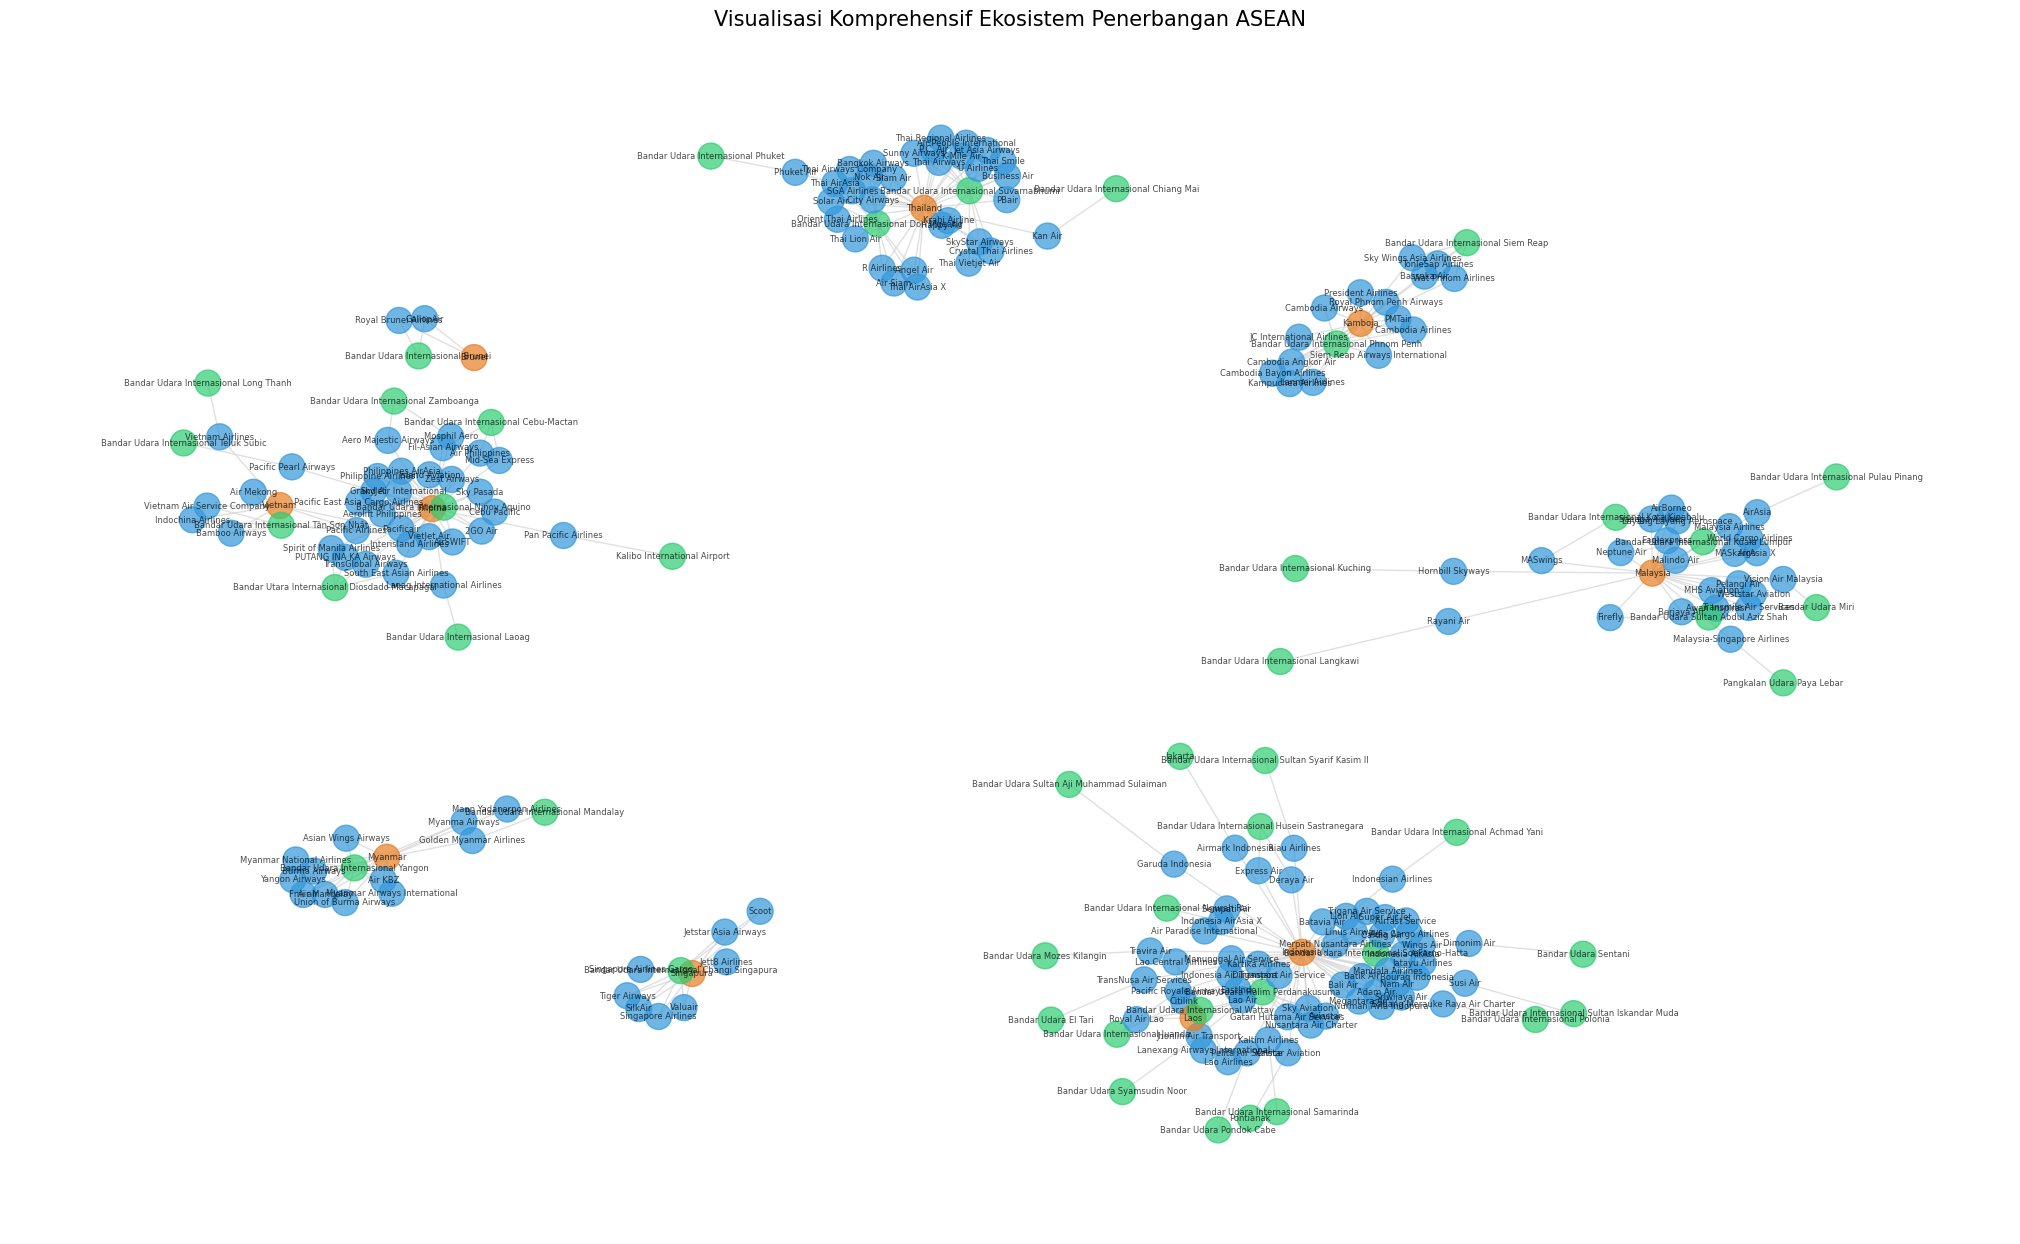

In [26]:
plt.figure(figsize=(20, 12))

# Color Mapping
colors = []
for node in G:
    ntype = G.nodes[node]['type']
    if ntype == 'Airline': colors.append('#3498db') # Biru
    elif ntype == 'Country': colors.append('#e67e22') # Oranye
    else: colors.append('#2ecc71') # Hijau

pos = nx.spring_layout(G, k=0.12, seed=42)
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=350, 
        font_size=6, alpha=0.7, edge_color='lightgray')

plt.title("Visualisasi Komprehensif Ekosistem Penerbangan ASEAN", fontsize=15)
plt.show()